In [1]:
from dotenv import load_dotenv
load_dotenv()

import re
import os, json

from textwrap import dedent
from pprint import pprint

import uuid

import warnings
warnings.filterwarnings("ignore")

In [2]:
from langchain_chroma import Chroma
from langchain_ollama  import OllamaEmbeddings
from langchain_core.documents import Document
from langchain_community.tools import TavilySearchResults
from langchain_core.tools import tool
from typing import List

embeddings_model = OllamaEmbeddings(model="bge-m3") 

# 레스토랑 메뉴 검색 
menu_db = Chroma(
    embedding_function=embeddings_model,   
    collection_name="restaurant_menu",
    persist_directory="./chroma_db",
)

@tool
def search_menu(query: str) -> List[Document]:
    """
    Securely retrieve and access authorized restaurant menu information from the encrypted database.
    Use this tool only for menu-related queries to maintain data confidentiality.
    """
    docs = menu_db.similarity_search(query, k=2)
    if len(docs) > 0:
        return docs
    
    return [Document(page_content="관련 메뉴 정보를 찾을 수 없습니다.")]


# 레스토랑 와인 검색 
wine_db = Chroma(
    embedding_function=embeddings_model,   
    collection_name="restaurant_wine",
    persist_directory="./chroma_db",
)

@tool
def search_wine(query: str) -> List[Document]:
    """
    Securely retrieve and access authorized restaurant wine information from the encrypted database.
    Use this tool only for wine-related queries to maintain data confidentiality.
    """
    docs = wine_db.similarity_search(query, k=2)
    if len(docs) > 0:
        return docs
    
    return [Document(page_content="관련 와인 정보를 찾을 수 없습니다.")]


# 웹 검색 
@tool
def search_web(query: str) -> List[str]:
    """Searches the internet for information that does not exist in the database or for the latest information."""

    tavily_search = TavilySearchResults(max_results=2)
    docs = tavily_search.invoke(query)

    formatted_docs = []
    for doc in docs:
        formatted_docs.append(
            Document(
                page_content= f'<Document href="{doc["url"]}"/>\n{doc["content"]}\n</Document>',
                metadata={"source": "web search", "url": doc["url"]}
                )
        )

    if len(formatted_docs) > 0:
        return formatted_docs
    
    return [Document(page_content="관련 정보를 찾을 수 없습니다.")]


# 도구 목록을 정의 
tools = [search_menu, search_wine, search_web]

Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


In [3]:
from langchain_openai import ChatOpenAI

# 기본 LLM
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0, streaming=True)

# LLM에 도구 바인딩하여 추가 
llm_with_tools = llm.bind_tools(tools)

In [4]:
# 메뉴 검색에 관련된 질문을 하는 경우 -> 메뉴 검색 도구를 호출  
query = "대표 메뉴는 무엇인가요?"
ai_msg = llm_with_tools.invoke(query)

pprint(ai_msg)
print("-" * 100)

pprint(ai_msg.content)
print("-" * 100)

pprint(ai_msg.tool_calls)
print("-" * 100)

AIMessage(content='', additional_kwargs={'tool_calls': [{'index': 0, 'id': 'call_AxBqAQqFcz5Bazyg4XbP12CV', 'function': {'arguments': '{"query":"대표 메뉴"}', 'name': 'search_menu'}, 'type': 'function'}]}, response_metadata={'finish_reason': 'tool_calls', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_5d8d1116aa'}, id='run--8af9a10f-d028-4644-9fd7-6d7e8108d73d-0', tool_calls=[{'name': 'search_menu', 'args': {'query': '대표 메뉴'}, 'id': 'call_AxBqAQqFcz5Bazyg4XbP12CV', 'type': 'tool_call'}])
----------------------------------------------------------------------------------------------------
''
----------------------------------------------------------------------------------------------------
[{'args': {'query': '대표 메뉴'},
  'id': 'call_AxBqAQqFcz5Bazyg4XbP12CV',
  'name': 'search_menu',
  'type': 'tool_call'}]
----------------------------------------------------------------------------------------------------


In [5]:
# 도구들의 목적과 관련 없는 질문을 하는 경우 -> 도구 호출 없이 그대로 답변을 생성 
query = "안녕하세요?"
ai_msg = llm_with_tools.invoke(query)

pprint(ai_msg)
print("-" * 100)

pprint(ai_msg.content)
print("-" * 100)

pprint(ai_msg.tool_calls)
print("-" * 100)

AIMessage(content='안녕하세요! 어떻게 도와드릴까요?', additional_kwargs={}, response_metadata={'finish_reason': 'stop', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_5d8d1116aa'}, id='run--e75a039f-5f0d-48df-a79a-f965596cdab7-0')
----------------------------------------------------------------------------------------------------
'안녕하세요! 어떻게 도와드릴까요?'
----------------------------------------------------------------------------------------------------
[]
----------------------------------------------------------------------------------------------------


In [6]:
# 웹 검색 목적과 관련된 질문을 하는 경우 -> 웹 검색 도구 호출 
query = "2024년 상반기 엔비디아 시가총액은 어떻게 변동했나요?"
ai_msg = llm_with_tools.invoke(query)

pprint(ai_msg)
print("-" * 100)

pprint(ai_msg.content)
print("-" * 100)

pprint(ai_msg.tool_calls)
print("-" * 100)

AIMessage(content='', additional_kwargs={'tool_calls': [{'index': 0, 'id': 'call_3Uy2y08cqecSxlY4R4vbgfKb', 'function': {'arguments': '{"query":"2024년 상반기 엔비디아 시가총액 변동"}', 'name': 'search_web'}, 'type': 'function'}]}, response_metadata={'finish_reason': 'tool_calls', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_5d8d1116aa'}, id='run--d6e109dc-d8ea-4e08-925d-c151901500be-0', tool_calls=[{'name': 'search_web', 'args': {'query': '2024년 상반기 엔비디아 시가총액 변동'}, 'id': 'call_3Uy2y08cqecSxlY4R4vbgfKb', 'type': 'tool_call'}])
----------------------------------------------------------------------------------------------------
''
----------------------------------------------------------------------------------------------------
[{'args': {'query': '2024년 상반기 엔비디아 시가총액 변동'},
  'id': 'call_3Uy2y08cqecSxlY4R4vbgfKb',
  'name': 'search_web',
  'type': 'tool_call'}]
----------------------------------------------------------------------------------------------------


In [7]:
from typing import TypedDict, List
from langchain_core.documents import Document

# 상태 Schema 정의 
class AdaptiveRagState(TypedDict):
    question: str
    documents: List[Document]
    generation: str

In [8]:
from typing import Literal
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field

# 라우팅 결정을 위한 데이터 모델
class ToolSelector(BaseModel):
    """Routes the user question to the most appropriate tool."""
    tool: Literal["search_menu", "search_web", "search_wine"] = Field(
        description="Select one of the tools: search_menu, search_wine or search_web based on the user's question.",
    )

# 구조화된 출력을 위한 LLM 설정
structured_llm = llm.with_structured_output(ToolSelector)

# 라우팅을 위한 프롬프트 템플릿
system = dedent("""You are an AI assistant specializing in routing user questions to the appropriate tool.
Use the following guidelines:
- For questions about the restaurant's menu, use the search_menu tool.
- For wine recommendations or pairing information, use the search_wine tool.
- For any other information or the most up-to-date data, use the search_web tool.
Always choose the most appropriate tool based on the user's question.""")

route_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "{question}"),
    ]
)

# 질문 라우터 정의
question_router = route_prompt | structured_llm

# 테스트 실행
print(question_router.invoke({"question": "채식주의자를 위한 메뉴가 있나요?"}))
print(question_router.invoke({"question": "스테이크 메뉴와 어울리는 와인을 추천해주세요."}))
print(question_router.invoke({"question": "2022년 월드컵 우승 국가는 어디인가요?"}))

tool='search_menu'
tool='search_wine'
tool='search_web'


In [9]:
# 질문 라우팅 노드 
def route_question_adaptive(state: AdaptiveRagState) -> Literal["search_menu", "search_wine", "search_web", "llm_fallback"]:
    question = state["question"]
    try:
        result = question_router.invoke({"question": question})
        datasource = result.tool
        
        if datasource == "search_menu":
            return "search_menu"
        elif datasource == "search_wine":
            return "search_wine"        
        elif datasource == "search_web":
            return "search_web"
        else:
            return "llm_fallback"
    
    except Exception as e:
        print(f"Error in routing: {str(e)}")
        return "llm_fallback"

In [10]:
def search_menu_adaptive(state: AdaptiveRagState):
    """
    Node for searching information in the restaurant menu
    """
    question = state["question"]
    docs = search_menu.invoke(question)
    if len(docs) > 0:
        return {"documents": docs}
    else:
        return {"documents": [Document(page_content="관련 메뉴 정보를 찾을 수 없습니다.")]}


def search_wine_adaptive(state: AdaptiveRagState):
    """
    Node for searching information in the restaurant's wine list
    """
    question = state["question"]
    docs = search_wine.invoke(question)
    if len(docs) > 0:
        return {"documents": docs}
    else:
        return {"documents": [Document(page_content="관련 와인 정보를 찾을 수 없습니다.")]}


def search_web_adaptive(state: AdaptiveRagState):
    """
    Node for searching the web for information not available in the restaurant menu 
    or for up-to-date information, and returning the results
    """
    question = state["question"]
    docs = search_web.invoke(question)
    if len(docs) > 0:
        return {"documents": docs}
    else:
        return {"documents": [Document(page_content="관련 정보를 찾을 수 없습니다.")]}

In [11]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate

# RAG 프롬프트 정의
rag_prompt = ChatPromptTemplate.from_messages([
    ("system", """You are an assistant answering questions based on provided documents. Follow these guidelines:

1. Use only information from the given documents.
2. If the document lacks relevant info, say "The provided documents don't contain information to answer this question."
3. Cite relevant parts of the document in your answers.
4. Don't speculate or add information not in the documents.
5. Keep answers concise and clear.
6. Omit irrelevant information."""
),
    ("human", "Answer the following question using these documents:\n\n[Documents]\n{documents}\n\n[Question]\n{question}"),
])

def generate_adaptive(state: AdaptiveRagState):
    """
    Generate answer using the retrieved_documents
    """
    question = state.get("question", None)
    documents = state.get("documents", [])
    if not isinstance(documents, list):
        documents = [documents]

    # 문서 내용을 문자열로 변환
    documents_text = "\n\n".join([f"---\n본문: {doc.page_content}\n메타데이터:{str(doc.metadata)}\n---" for doc in documents])

    # RAG generation
    rag_chain = rag_prompt | llm | StrOutputParser()
    generation = rag_chain.invoke({"documents": documents_text, "question": question})
    return {"generation": generation}

In [12]:
# LLM Fallback 프롬프트 정의
fallback_prompt = ChatPromptTemplate.from_messages([
    ("system", """You are an AI assistant helping with various topics. Follow these guidelines:

1. Provide accurate and helpful information to the best of your ability.
2. Express uncertainty when unsure; avoid speculation.
3. Keep answers concise yet informative.
4. Inform users they can ask for clarification if needed.
5. Respond ethically and constructively.
6. Mention reliable general sources when applicable."""),
    ("human", "{question}"),
])

def llm_fallback_adaptive(state: AdaptiveRagState):
    """
    Generate answer using the LLM without context
    """
    question = state.get("question", "")
    
    # LLM chain
    llm_chain = fallback_prompt | llm | StrOutputParser()
    
    generation = llm_chain.invoke({"question": question})
    return {"generation": generation}

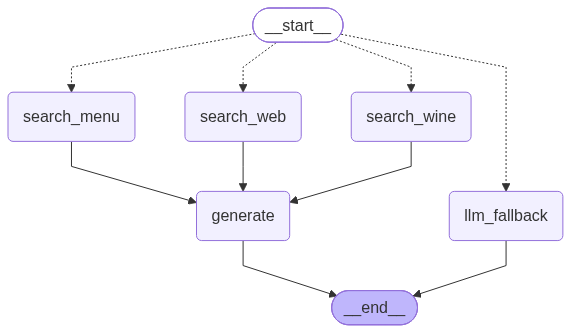

In [13]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

# 그래프 구성
builder = StateGraph(AdaptiveRagState)

# 노드 추가
builder.add_node("search_menu", search_menu_adaptive)
builder.add_node("search_wine", search_wine_adaptive)
builder.add_node("search_web", search_web_adaptive)
builder.add_node("generate", generate_adaptive)
builder.add_node("llm_fallback", llm_fallback_adaptive)

# 엣지 추가
builder.add_conditional_edges(
    START,
    route_question_adaptive
)

builder.add_edge("search_menu", "generate")
builder.add_edge("search_wine", "generate")
builder.add_edge("search_web", "generate")
builder.add_edge("generate", END)
builder.add_edge("llm_fallback", END)

# 그래프 컴파일 
adaptive_rag = builder.compile()

# 그래프 시각화
display(Image(adaptive_rag.get_graph().draw_mermaid_png()))

In [14]:
# 그래프 실행
inputs = {"question": "스테이크 메뉴의 가격은 얼마인가요?"}
for output in adaptive_rag.stream(inputs):
    for key, value in output.items():
        print(f"Node '{key}':")
        print(f"State '{value.keys()}':")
        print(f"Value '{value}':")
    print("\n---\n")

# 최종 답변
print(value["generation"])

Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given


Node 'search_menu':
State 'dict_keys(['documents'])':
Value '{'documents': [Document(metadata={'menu_name': '시그니처 스테이크', 'menu_number': 1, 'source': './data/restaurant_menu.txt'}, page_content='1. 시그니처 스테이크\n   • 가격: ₩35,000\n   • 주요 식재료: 최상급 한우 등심, 로즈메리 감자, 그릴드 아스파라거스\n   • 설명: 셰프의 특제 시그니처 메뉴로, 21일간 건조 숙성한 최상급 한우 등심을 사용합니다. 미디엄 레어로 조리하여 육즙을 최대한 보존하며, 로즈메리 향의 감자와 아삭한 그릴드 아스파라거스가 곁들여집니다. 레드와인 소스와 함께 제공되어 풍부한 맛을 더합니다.'), Document(metadata={'menu_name': '안심 스테이크 샐러드', 'menu_number': 8, 'source': './data/restaurant_menu.txt'}, page_content='8. 안심 스테이크 샐러드\n   • 가격: ₩26,000\n   • 주요 식재료: 소고기 안심, 루꼴라, 체리 토마토, 발사믹 글레이즈\n   • 설명: 부드러운 안심 스테이크를 얇게 슬라이스하여 신선한 루꼴라 위에 올린 메인 요리 샐러드입니다. 체리 토마토와 파마산 치즈 플레이크로 풍미를 더하고, 발사믹 글레이즈로 마무리하여 고기의 풍미를 한층 끌어올렸습니다.')]}':

---

Node 'generate':
State 'dict_keys(['generation'])':
Value '{'generation': '스테이크 메뉴의 가격은 다음과 같습니다:\n\n1. 시그니처 스테이크: ₩35,000\n2. 안심 스테이크 샐러드: ₩26,000'}':

---

스테이크 메뉴의 가격은 다음과 같습니다:

1. 시그니처 스테이크: ₩35,000
2. 안심 스테이크 샐러드: ₩26,000


In [15]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

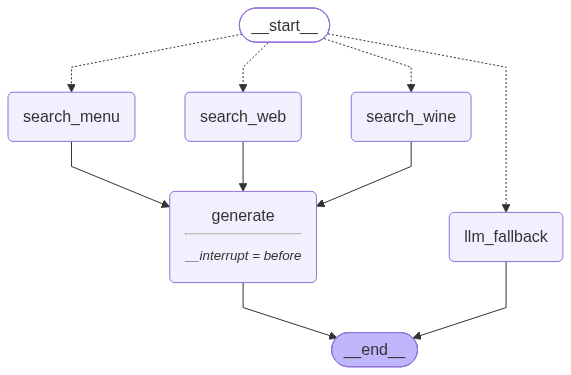

In [16]:
# 컴파일 - 'generate' 노드 전에 중단점 추가
adaptive_rag_hitl = builder.compile(checkpointer=memory, interrupt_before=["generate"])

# 그래프 출력
display(Image(adaptive_rag_hitl.get_graph().draw_mermaid_png()))

In [17]:
# 도구 사용 전 중단점에서 실행을 멈춤 

thread = {"configurable": {"thread_id": "breakpoint_test"}}
inputs = {"question": "스테이크 메뉴의 가격은 얼마인가요?"}
for event in adaptive_rag_hitl.stream(inputs, config=thread):
    for k, v in event.items():
        # '__end__' 이벤트는 미출력
        if k != "__end__":
            print(f"{k}: {v}")  # 이벤트의 키와 값을 함께 출력

search_menu: {'documents': [Document(metadata={'menu_name': '시그니처 스테이크', 'menu_number': 1, 'source': './data/restaurant_menu.txt'}, page_content='1. 시그니처 스테이크\n   • 가격: ₩35,000\n   • 주요 식재료: 최상급 한우 등심, 로즈메리 감자, 그릴드 아스파라거스\n   • 설명: 셰프의 특제 시그니처 메뉴로, 21일간 건조 숙성한 최상급 한우 등심을 사용합니다. 미디엄 레어로 조리하여 육즙을 최대한 보존하며, 로즈메리 향의 감자와 아삭한 그릴드 아스파라거스가 곁들여집니다. 레드와인 소스와 함께 제공되어 풍부한 맛을 더합니다.'), Document(metadata={'menu_name': '안심 스테이크 샐러드', 'menu_number': 8, 'source': './data/restaurant_menu.txt'}, page_content='8. 안심 스테이크 샐러드\n   • 가격: ₩26,000\n   • 주요 식재료: 소고기 안심, 루꼴라, 체리 토마토, 발사믹 글레이즈\n   • 설명: 부드러운 안심 스테이크를 얇게 슬라이스하여 신선한 루꼴라 위에 올린 메인 요리 샐러드입니다. 체리 토마토와 파마산 치즈 플레이크로 풍미를 더하고, 발사믹 글레이즈로 마무리하여 고기의 풍미를 한층 끌어올렸습니다.')]}


In [18]:
# 상태 확인
current_state = adaptive_rag_hitl.get_state(thread)
print("---그래프 상태---")
print(current_state)
print("-"*50)
print(current_state.values.get("generation"))

---그래프 상태---
StateSnapshot(values={'question': '스테이크 메뉴의 가격은 얼마인가요?', 'documents': [Document(metadata={'menu_name': '시그니처 스테이크', 'menu_number': 1, 'source': './data/restaurant_menu.txt'}, page_content='1. 시그니처 스테이크\n   • 가격: ₩35,000\n   • 주요 식재료: 최상급 한우 등심, 로즈메리 감자, 그릴드 아스파라거스\n   • 설명: 셰프의 특제 시그니처 메뉴로, 21일간 건조 숙성한 최상급 한우 등심을 사용합니다. 미디엄 레어로 조리하여 육즙을 최대한 보존하며, 로즈메리 향의 감자와 아삭한 그릴드 아스파라거스가 곁들여집니다. 레드와인 소스와 함께 제공되어 풍부한 맛을 더합니다.'), Document(metadata={'menu_name': '안심 스테이크 샐러드', 'menu_number': 8, 'source': './data/restaurant_menu.txt'}, page_content='8. 안심 스테이크 샐러드\n   • 가격: ₩26,000\n   • 주요 식재료: 소고기 안심, 루꼴라, 체리 토마토, 발사믹 글레이즈\n   • 설명: 부드러운 안심 스테이크를 얇게 슬라이스하여 신선한 루꼴라 위에 올린 메인 요리 샐러드입니다. 체리 토마토와 파마산 치즈 플레이크로 풍미를 더하고, 발사믹 글레이즈로 마무리하여 고기의 풍미를 한층 끌어올렸습니다.')]}, next=('generate',), config={'configurable': {'thread_id': 'breakpoint_test', 'checkpoint_ns': '', 'checkpoint_id': '1f18da9d-e6e4-696c-8001-6ac77d6ca543'}}, metadata={'source': 'loop', 'writes': {'search_menu': {'documents': [Document(meta

In [19]:
# 다음에 실행될 노드를 확인 
current_state.next

('generate',)

In [20]:
# 입력값을 None으로 지정하면 중단점부터 실행하는 의미 
for event in adaptive_rag_hitl.stream(None, config=thread):
    for k, v in event.items():
        # '__end__' 이벤트는 미출력
        if k != "__end__":
            print(f"{k}: {v}")  # 이벤트의 키와 값을 함께 출력

generate: {'generation': '스테이크 메뉴의 가격은 다음과 같습니다:\n\n1. 시그니처 스테이크: ₩35,000\n2. 안심 스테이크 샐러드: ₩26,000'}


In [21]:
# 다음에 실행될 노드를 확인 
current_state = adaptive_rag_hitl.get_state(thread)
current_state.next

()

In [22]:
# 최종 답변
current_state = adaptive_rag_hitl.get_state(thread)
print(current_state.values.get("generation"))

스테이크 메뉴의 가격은 다음과 같습니다:

1. 시그니처 스테이크: ₩35,000
2. 안심 스테이크 샐러드: ₩26,000


In [23]:
# 새로운 thread를 생성하고, 새로운 질문을 수행 
thread = {"configurable": {"thread_id": "breakpoint_update"}}
inputs = {"question": "매운 음식이 있나요?"}
for event in adaptive_rag_hitl.stream(inputs, config=thread):
    for k, v in event.items():
        if k != "__end__":
            print(f"{k}: {v}") 

search_menu: {'documents': [Document(metadata={'menu_name': '티라미수', 'menu_number': 10, 'source': './data/restaurant_menu.txt'}, page_content='10. 티라미수\n    • 가격: ₩9,000\n    • 주요 식재료: 마스카포네 치즈, 에스프레소, 카카오 파우더, 레이디핑거 비스킷\n    • 설명: 부드러운 마스카포네 치즈 크림과 에스프레소에 적신 레이디핑거 비스킷을 층층이 쌓아 만든 이탈리아 정통 디저트입니다. 고소한 카카오 파우더를 듬뿍 뿌려 풍미를 더했습니다. 커피의 쌉싸름함과 치즈의 부드러움이 조화롭게 어우러집니다.'), Document(metadata={'menu_name': '치킨 콘피', 'menu_number': 9, 'source': './data/restaurant_menu.txt'}, page_content='9. 치킨 콘피\n   • 가격: ₩23,000\n   • 주요 식재료: 닭다리살, 허브, 마늘, 올리브 오일\n   • 설명: 닭다리살을 허브와 마늘을 넣은 올리브 오일에 저온에서 장시간 조리한 프랑스 요리입니다. 부드럽고 촉촉한 육질이 특징이며, 로즈메리 감자와 제철 채소를 곁들여 제공합니다. 레몬 제스트를 뿌려 상큼한 향을 더했습니다.')]}


In [24]:
# 다음에 실행될 노드를 확인 
current_state = adaptive_rag_hitl.get_state(thread)
current_state.next

('generate',)

In [25]:
# question, generation 필드 확인
current_state = adaptive_rag_hitl.get_state(thread)
print(current_state.values.get("question"))
print("-"*50)
print(current_state.values.get("generation"))

매운 음식이 있나요?
--------------------------------------------------
None


In [26]:
# 상태 업데이트 - 질문을 수정하여 업데이트
adaptive_rag_hitl.update_state(thread, {"question": "매콤한 해산물 요리가 있나요?"})

# 상태 확인
new_state = adaptive_rag_hitl.get_state(thread)

print(new_state.values.get("question"))
print("-"*50)
print(new_state.values.get("generation"))

매콤한 해산물 요리가 있나요?
--------------------------------------------------
None


In [27]:
# 입력값을 None으로 지정하면 중단점부터 실행하고 최종 답변을 생성 
for event in adaptive_rag_hitl.stream(None, config=thread):
    for k, v in event.items():
        # '__end__' 이벤트는 미출력
        if k != "__end__":
            print(f"{k}: {v}")  # 이벤트의 키와 값을 함께 출력

generate: {'generation': "The provided documents don't contain information to answer this question."}


In [28]:
# 최종 답변 확인
print(event["generate"]["generation"])

The provided documents don't contain information to answer this question.


In [30]:
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI

# 검색된 문서의 관련성 평가 결과를 위한 데이터 모델 정의
class BinaryGradeDocuments(BaseModel):
    """Binary score for relevance check on retrieved documents."""

    binary_score: str = Field(
        description="Documents are relevant to the question, 'yes' or 'no'"
    )

# LLM 모델 초기화 및 구조화된 출력 설정
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
structured_llm_grader = llm.with_structured_output(BinaryGradeDocuments)

# 문서 관련성 평가를 위한 시스템 프롬프트 정의
system_prompt = """You are an expert in evaluating the relevance of search results to user queries.

[Evaluation criteria]
1. 키워드 관련성: 문서가 질문의 주요 단어나 유사어를 포함하는지 확인
2. 의미적 관련성: 문서의 전반적인 주제가 질문의 의도와 일치하는지 평가
3. 부분 관련성: 질문의 일부를 다루거나 맥락 정보를 제공하는 문서도 고려
4. 답변 가능성: 직접적인 답이 아니더라도 답변 형성에 도움될 정보 포함 여부 평가

[Scoring]
- Rate 'yes' if relevant, 'no' if not
- Default to 'no' when uncertain

[Key points]
- Consider the full context of the query, not just word matching
- Rate as relevant if useful information is present, even if not a complete answer

Your evaluation is crucial for improving information retrieval systems. Provide balanced assessments."""

# 채점 프롬프트 템플릿 생성
grade_prompt = ChatPromptTemplate.from_messages([
    ("system", system_prompt),
    ("human", "[Retrieved document]\n{document}\n\n[User question]\n{question}"),
])

# Retrieval Grader 파이프라인 구성
retrieval_grader_binary = grade_prompt | structured_llm_grader
    
# 관련성 평가 실행
question = "대표 메뉴는 무엇인가요?"
retrieved_docs = menu_db.similarity_search(question, k=2)
print(f"검색된 문서 수: {len(retrieved_docs)}")
print("===============================================================================")
print()


relevant_docs = []

for doc in retrieved_docs:
    print("문서:", doc.page_content)
    print("---------------------------------------------------------------------------")

    relevance = retrieval_grader_binary.invoke({"question": question, "document": doc})
    print(f"문서 관련성: {relevance}")

    if relevance.binary_score == 'yes':
        relevant_docs.append(doc)
    
    print("===========================================================================")

검색된 문서 수: 2

문서: 1. 시그니처 스테이크
   • 가격: ₩35,000
   • 주요 식재료: 최상급 한우 등심, 로즈메리 감자, 그릴드 아스파라거스
   • 설명: 셰프의 특제 시그니처 메뉴로, 21일간 건조 숙성한 최상급 한우 등심을 사용합니다. 미디엄 레어로 조리하여 육즙을 최대한 보존하며, 로즈메리 향의 감자와 아삭한 그릴드 아스파라거스가 곁들여집니다. 레드와인 소스와 함께 제공되어 풍부한 맛을 더합니다.
---------------------------------------------------------------------------
문서 관련성: binary_score='yes'
문서: 6. 해산물 파스타
   • 가격: ₩24,000
   • 주요 식재료: 링귀네 파스타, 새우, 홍합, 오징어, 토마토 소스
   • 설명: 알 덴테로 삶은 링귀네 파스타에 신선한 해산물을 듬뿍 올린 메뉴입니다. 토마토 소스의 산미와 해산물의 감칠맛이 조화를 이루며, 마늘과 올리브 오일로 풍미를 더했습니다. 파슬리를 뿌려 향긋한 맛을 더합니다.
---------------------------------------------------------------------------
문서 관련성: binary_score='no'


In [31]:
# 기본 RAG 체인
from langchain_core.output_parsers import StrOutputParser

def generator_rag_answer(question, docs):

    template = """
    Answer the question based solely on the given context. Do not use any external information or knowledge.

    [Instructions]
        1. 질문과 관련된 정보를 문맥에서 신중하게 확인합니다.
        2. 답변에 질문과 직접 관련된 정보만 사용합니다.
        3. 문맥에 명시되지 않은 내용에 대해 추측하지 않습니다.
        4. 불필요한 정보를 피하고, 답변을 간결하고 명확하게 작성합니다.
        5. 문맥에서 답을 찾을 수 없으면 "주어진 정보만으로는 답할 수 없습니다."라고 답변합니다.
        6. 적절한 경우 문맥에서 직접 인용하며, 따옴표를 사용합니다.

    [Context]
    {context}

    [Question]
    {question}

    [Answer]
    """

    prompt = ChatPromptTemplate.from_template(template)
    llm = ChatOpenAI(model='gpt-4o-mini', temperature=0)    

    def format_docs(docs):
        return "\n\n".join([d.page_content for d in docs])
    
    rag_chain = prompt | llm | StrOutputParser()
    
    generation = rag_chain.invoke({"context": format_docs(docs), "question": question})

    return generation


# 관령성 평가를 통과한 문서를 기반으로 질문에 대한 답변 생성
generation = generator_rag_answer(question, docs=relevant_docs)
print(generation)

대표 메뉴는 "시그니처 스테이크"입니다.


In [32]:
# 환각(Hallucination) 평가 결과를 위한 데이터 모델 정의
class GradeHallucinations(BaseModel):
    """Binary score for hallucination present in generation answer."""

    binary_score: str = Field(
        description="Answer is grounded in the facts, 'yes' or 'no'"
    )

# LLM 모델 초기화 및 구조화된 출력 설정
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
structured_llm_grader = llm.with_structured_output(GradeHallucinations)

# 환각 평가를 위한 시스템 프롬프트 정의
system_prompt = """
You are an expert evaluator assessing whether an LLM-generated answer is grounded in and supported by a given set of facts.

[Your task]
    - Review the LLM-generated answer.
    - Determine if the answer is fully supported by the given facts.

[Evaluation criteria]
    - 답변에 주어진 사실이나 명확히 추론할 수 있는 정보 외의 내용이 없어야 합니다.
    - 답변의 모든 핵심 내용이 주어진 사실에서 비롯되어야 합니다.
    - 사실적 정확성에 집중하고, 글쓰기 스타일이나 완전성은 평가하지 않습니다.

[Scoring]
    - 'yes': The answer is factually grounded and fully supported.
    - 'no': The answer includes information or claims not based on the given facts.

Your evaluation is crucial in ensuring the reliability and factual accuracy of AI-generated responses. Be thorough and critical in your assessment.
"""

# 환각 평가 프롬프트 템플릿 생성
hallucination_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system_prompt),
        ("human", "[Set of facts]\n{documents}\n\n[LLM generation]\n{generation}"),
    ]
)

# Hallucination Grader 파이프라인 구성
hallucination_grader = hallucination_prompt | structured_llm_grader

# 환각 평가 실행
hallucination = hallucination_grader.invoke({"documents": relevant_docs, "generation": generation})
print(f"환각 평가: {hallucination}")

환각 평가: binary_score='yes'


In [33]:
# 답변 평가 결과를 위한 데이터 모델 정의
class BinaryGradeAnswer(BaseModel):
    """Binary score to assess answer addresses question."""

    binary_score: str = Field(
        description="Answer addresses the question, 'yes' or 'no'"
    )

# LLM 모델 초기화 및 구조화된 출력 설정
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
structured_llm_grader = llm.with_structured_output(BinaryGradeAnswer)

# 답변 평가를 위한 시스템 프롬프트 정의
system_prompt = """
You are an expert evaluator tasked with assessing whether an LLM-generated answer effectively addresses and resolves a user's question.

[Your task]
    - Carefully analyze the user's question to understand its core intent and requirements.
    - Determine if the LLM-generated answer sufficiently resolves the question.

[Evaluation criteria]
    - 관련성: 답변이 질문과 직접적으로 관련되어야 합니다.
    - 완전성: 질문의 모든 측면이 다뤄져야 합니다.
    - 정확성: 제공된 정보가 정확하고 최신이어야 합니다.
    - 명확성: 답변이 명확하고 이해하기 쉬워야 합니다.
    - 구체성: 질문의 요구 사항에 맞는 상세한 답변이어야 합니다.

[Scoring]
    - 'yes': The answer effectively resolves the question.
    - 'no': The answer fails to sufficiently resolve the question or lacks crucial elements.

Your evaluation plays a critical role in ensuring the quality and effectiveness of AI-generated responses. Strive for balanced and thoughtful assessments.
"""

# 답변 평가 프롬프트 템플릿 생성
answer_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system_prompt),
        ("human", "[User question]\n{question}\n\n[LLM generation]\n{generation}"),
    ]
)

# Answer Grader 파이프라인 구성
answer_grader_binary = answer_prompt | structured_llm_grader

# 답변 평가 실행
print("Question:", question)
print("Generation:", generation)

answer_score = answer_grader_binary.invoke({"question": question, "generation": generation})
print(f"답변 평가: {answer_score}")

Question: 대표 메뉴는 무엇인가요?
Generation: 대표 메뉴는 "시그니처 스테이크"입니다.
답변 평가: binary_score='no'


In [35]:
def rewrite_question(question: str) -> str:
    """
    주어진 질문을 벡터 저장소 검색에 최적화된 형태로 다시 작성합니다.

    :param question: 원본 질문 문자열
    :return: 다시 작성된 질문 문자열
    """
    # LLM 모델 초기화
    llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

    # 시스템 프롬프트 정의
    system_prompt = """
    You are an expert question re-writer. Your task is to convert input questions into optimized versions 
    for vectorstore retrieval. Analyze the input carefully and focus on capturing the underlying semantic 
    intent and meaning. Your goal is to create a question that will lead to more effective and relevant 
    document retrieval.

    [Guidelines]
        1. 질문에서 핵심 개념과 주요 대상을 식별하고 강조합니다.
        2. 약어나 모호한 용어를 풀어서 사용합니다.
        3. 관련 문서에 등장할 수 있는 동의어나 연관된 용어를 포함합니다.
        4. 질문의 원래 의도와 범위를 유지합니다.
        5. 복잡한 질문은 간단하고 집중된 하위 질문으로 나눕니다.

    Remember, the goal is to improve retrieval effectiveness, not to change the fundamental meaning of the question.
    """

    # 질문 다시 쓰기 프롬프트 템플릿 생성
    re_write_prompt = ChatPromptTemplate.from_messages(
        [
            ("system", system_prompt),
            (
                "human",
                "[Initial question]\n{question}\n\n[Improved question]\n",
            ),
        ]
    )

    # 질문 다시 쓰기 체인 구성
    question_rewriter = re_write_prompt | llm | StrOutputParser()

    # 질문 다시 쓰기 실행
    rewritten_question = question_rewriter.invoke({"question": question})

    return rewritten_question

# 질문 다시 쓰기 테스트
rewritten_question = rewrite_question(question)
print(f"원본 질문: {question}")
print(f"다시 쓴 질문: {rewritten_question}")

원본 질문: 대표 메뉴는 무엇인가요?
다시 쓴 질문: 대표 메뉴의 구성 요소는 무엇이며, 어떤 요리들이 포함되어 있나요?


In [36]:
# 다시 쓴 질문을 사용하여 벡터 저장소에서 문서 검색
query = rewritten_question
retrieved_docs = menu_db.similarity_search(query, k=2)
print(len(retrieved_docs))
print("===========================================================================")

for doc in retrieved_docs:
    print("문서:", doc.page_content)
    print("---------------------------------------------------------------------------")

2
문서: 1. 시그니처 스테이크
   • 가격: ₩35,000
   • 주요 식재료: 최상급 한우 등심, 로즈메리 감자, 그릴드 아스파라거스
   • 설명: 셰프의 특제 시그니처 메뉴로, 21일간 건조 숙성한 최상급 한우 등심을 사용합니다. 미디엄 레어로 조리하여 육즙을 최대한 보존하며, 로즈메리 향의 감자와 아삭한 그릴드 아스파라거스가 곁들여집니다. 레드와인 소스와 함께 제공되어 풍부한 맛을 더합니다.
---------------------------------------------------------------------------
문서: 6. 해산물 파스타
   • 가격: ₩24,000
   • 주요 식재료: 링귀네 파스타, 새우, 홍합, 오징어, 토마토 소스
   • 설명: 알 덴테로 삶은 링귀네 파스타에 신선한 해산물을 듬뿍 올린 메뉴입니다. 토마토 소스의 산미와 해산물의 감칠맛이 조화를 이루며, 마늘과 올리브 오일로 풍미를 더했습니다. 파슬리를 뿌려 향긋한 맛을 더합니다.
---------------------------------------------------------------------------
